# AMS from scratch: splitting without choosing the levels

[`ips_simple_sequence.ipynb`](ips_simple_sequence.ipynb) built fixed-level splitting
from scratch: pick a ladder of shells in advance, fly a particle cloud shell to shell,
cull and resample. Its one weakness is the word *pick*. The shells are a tuning input:
spaced too aggressively, a level goes empty (`S_k = 0`) and the replication returns 0 —
the collapse signal in [`blueskycdarr/ips.py`](../blueskycdarr/ips.py); spaced too
gently, effort is wasted on easy shells. And in strongly-resolved cells the minimum-
separation distribution offers no good place to put a shell at all: most encounters are
resolved far from the boundary, a thin tail comes close, and the gap in between is
exactly where a fixed shell goes empty.

**Adaptive multilevel splitting** (Cérou & Guyader 2007) removes the input: the cloud
places its own levels. Score every particle by the thing itself — the final
running-minimum separation of its **finished** encounter. Then, repeatedly:

1. the **level** `L` is the k-th worst score in the cloud;
2. **kill** every particle with score at-or-above `L` (`K ≥ k` when scores tie);
3. **branch**: each killed slot is refilled by cloning a random survivor *from the
   first moment its own flight crossed `L`*, flown to a new ending on fresh noise;
4. multiply the estimate by `(N − K)/N`; once `L` itself is inside the rare set, stop:
   `P̂ = Π_j (N − K_j)/N × (final rare fraction)`.

The levels sit wherever the cloud's worst members happen to sit, so no level is ever
placed in a gap, and each iteration provably lowers `L` — the ladder builds itself all
the way down to the protected zone.

> **The from-scratch rule.** There is **no packaged AMS** in `blueskycdarr` — this
> notebook is the implementation, on the same engine sequence as before: init → spawn →
> step → **replay** → snapshot → restore. Only the simulator is imported (`engine`,
> `episode`, `rng`, `config`, and the top-level names); `blueskycdarr.ips` appears in
> exactly one place — the final cell — as the fixed-level *anchor* to compare against.
> With no packaged twin to reproduce, verification is threefold: the initial cloud is
> asserted identical to packaged Monte-Carlo episodes (`run_episode`), every branch
> replay is asserted bit-identical to the recorded flight it reopens, and the final
> estimate is compared to the fixed-level anchor **by ratio** (the project's convention
> — counts and point estimates only, no intervals).

Same cell as before: crossing angle **90°**, miss distance 0 m, `pos_ci95 = 40 m`,
`vel_ci95 = 1 m/s`, reception 0.8, latency 0.3 s, protected zone `rpz = 50 m`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from blueskycdarr import MULTIROTOR, Config, PairwiseEncounter
from blueskycdarr.config import CommConfig, SimulationConfig, UncertaintyConfig
from blueskycdarr.engine import (
    PairwiseWorld,
    WorldSnapshot,
    discard_pending_commands,
    reset_world,
)
from blueskycdarr.episode import (
    EpisodeState,
    EpisodeStreams,
    advance,
    episode_context,
    init_episode,
    run_episode,
)
from blueskycdarr.rng import child, generator, root_seed_sequence

# --- the cell ---------------------------------------------------------------------
DPSI, POS_CI95, VEL_CI95 = 90.0, 40.0, 1.0
N, K_KILL, SEED = 200, 20, 4
RPZ, MAX_ITERS = 50.0, 200

SCENARIO = PairwiseEncounter(pairs=(1, 1), dpsi=DPSI, dcpa=0.0, tlos=20.0)
CONFIG = Config(
    uncertainty=UncertaintyConfig(pos_ci95=POS_CI95, vel_ci95=VEL_CI95),
    comm=CommConfig(reception_prob=0.8, latency_s=0.3),
    simulation=SimulationConfig(t_max=90.0),
)
ctx = episode_context(SCENARIO.n_pairs, MULTIROTOR, CONFIG)
DT = CONFIG.simulation.dt
assert CONFIG.conflict.rpz == RPZ

world = None  # the one live engine slot every particle passes through

# --- plotting style (blue/orange/aqua + neutral grays) -----------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY, INK, MUTED, RED = "#b6b5ae", "#0b0b0b", "#52514e", "#e34948"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#eeedea", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.constrained_layout.use": True,
})

print(f"N = {N} particles, kill the worst k = {K_KILL} per iteration, "
      f"dt = {DT} s, rpz = {RPZ:g} m")

N = 200 particles, kill the worst k = 20 per iteration, dt = 0.2 s, rpz = 50 m


## 1 · A particle is a finished flight

Fixed-level IPS stops its particles *at* shells; AMS scores **complete encounters**.
So the AMS initial cloud is, literally, a Monte-Carlo batch: each particle is one
episode flown start to finish, and its score is the final running-minimum separation.

The cell below flies one such episode by hand — spawn the pair, initialise the episode
state, call `advance` until it returns `False` — and then proves the "literally": the
packaged Monte-Carlo episode (`run_episode`), handed the same seed, must report the
**identical** minimum separation, because the by-hand loop consumes the same streams in
the same order (geometry from child 0 of the seed, forward noise from children 1–4,
`init_episode` and the flight sharing one bundle). One `discard_pending_commands()`
follows every finished flight: an encounter that ends on a command-stacking CDR tick
leaves commands stacked but never flown, and they must not leak into the next
particle's world.

In [2]:
seed_demo = child(root_seed_sequence(SEED), 99)   # a scratch corner of the stream tree

geom = SCENARIO.draw_geometry(generator(child(seed_demo, 0)))
world = PairwiseWorld(SCENARIO, geom, MULTIROTOR, CONFIG.conflict, CONFIG.simulation)
bundle = EpisodeStreams.from_episode_seq(seed_demo)
st = init_episode(world, ctx, bundle)

leg0 = []                                          # the flight's (t, separation) record
while advance(world, ctx, st, bundle,
              recorder=lambda t, truth, d: leg0.append((t, float(d[0])))):
    pass
discard_pending_commands()
score0 = float(st.min_sep[0])
reset_world()

print(f"one finished flight: {len(leg0)} observations, settled = {st.settled}, "
      f"t_end = {leg0[-1][0]:.1f} s")
print(f"score = final running-minimum separation = {score0:.2f} m")

res = run_episode(SCENARIO, MULTIROTOR, CONFIG, seed_demo)   # the packaged MC episode
assert float(res.min_sep[0]) == score0, "by-hand flight != packaged MC episode"
print(f"run_episode, same seed: min_sep = {float(res.min_sep[0]):.2f} m — identical")

one finished flight: 156 observations, settled = True, t_end = 31.0 s
score = final running-minimum separation = 93.03 m
run_episode, same seed: min_sep = 93.03 m — identical


## 2 · Reopening a finished flight in the middle

Here is AMS's mechanical problem. To branch, it needs a survivor's engine state at the
first moment that survivor's flight crossed a level — but the level is the k-th worst
score of the *current* cloud, unknowable while the survivor was flying. Fixed-level
IPS could snapshot at its shells because the shells were known in advance. AMS cannot,
and snapshotting the world at *every* step, just in case, would copy the entire engine
hundreds of times per flight.

The escape is the reproducibility contract. A flight is a **pure function of its
seed**: respawn the same encounter, re-fly it with a stream bundle rebuilt from the
same seed, and the engine produces the same flight, bit for bit — so stopping the
replay at the crossing *is* standing at the state AMS needs, and it costs one cheap
re-fly instead of hundreds of stored snapshots. Below, section 1's flight is reopened
at an arbitrary level: the replayed prefix is asserted **exactly equal** to the
recorded one, and then the flight is continued on a *fresh* bundle — same past,
different future, a different final score. That pair (identical under the same
streams, divergent under fresh ones) is the previous notebook's clone contract, driven
this time from a respawn rather than a held snapshot.

In [3]:
L_DEMO = float(round(score0 + 25.0))   # any level the flight is known to have crossed

geom = SCENARIO.draw_geometry(generator(child(seed_demo, 0)))     # respawn from seed
world = PairwiseWorld(SCENARIO, geom, MULTIROTOR, CONFIG.conflict, CONFIG.simulation)
bundle = EpisodeStreams.from_episode_seq(seed_demo)               # same streams again
st = init_episode(world, ctx, bundle)

prefix, running = [], True
while running and float(st.min_sep[0]) >= L_DEMO:                 # replay to the crossing
    running = advance(world, ctx, st, bundle,
                      recorder=lambda t, truth, d: prefix.append((t, float(d[0]))))

assert running, "the flight ended before crossing — pick a level it actually crossed"
assert prefix == leg0[:len(prefix)], "replay diverged from the recorded flight!"
print(f"reopened at L = {L_DEMO:g} m: {len(prefix)} observations replayed "
      f"(t = {prefix[-1][0]:.1f} s), prefix bit-identical to the record")

fresh = EpisodeStreams.from_episode_seq(child(seed_demo, 7))      # now innovate
while advance(world, ctx, st, fresh):
    pass
discard_pending_commands()
print(f"fresh continuation from there: score {score0:.2f} m -> "
      f"{float(st.min_sep[0]):.2f} m — same past, different future")
reset_world()

reopened at L = 118 m: 90 observations replayed (t = 17.8 s), prefix bit-identical to the record
fresh continuation from there: score 93.03 m -> 91.23 m — same past, different future


## 3 · The estimator, from scratch

Four pieces, built on nothing but section 1 (fly to the end) and section 2 (reopen at
a level):

- **`AMSParticle`** — a finished flight, remembered by how to reproduce it: an
  `origin` (how to stand the start of its leg back up — a spawn seed, or a world
  snapshot taken when it was branched), the `leg_seq` its leg's streams came from, its
  `score`, and the recorded `(t, separation)` series (`inh` inherited from ancestors +
  its own `leg`) — the series exists for the figure and the replay assert, never for
  the mechanics. Treat as immutable.
- **`materialise`** — stand a leg's starting state back up: respawn from the seed, or
  restore the branch snapshot. Returns the state and the matching stream bundle
  (spawn origins share one bundle between `init_episode` and the flight, exactly like
  `run_episode`; branch origins get a fresh bundle from `leg_seq`).
- **`fly_to_end`** — section 1's loop: advance until the encounter closes, return the
  score, discard the dead world's leftover commands.
- **`branch_clone`** — section 2's replay, made load-bearing: reproduce the parent's
  leg to its first observation strictly below the level (**asserting bit-identity
  against the parent's record, every time**), snapshot there, then fly to a new ending
  on fresh streams. The snapshot is what keeps replay cheap forever after: it
  *flattens the lineage*, so branching a clone-of-a-clone replays one leg, never the
  whole ancestry. One edge: if the parent's leg *ended* on the very observation that
  crossed, there is no future left to innovate — the clone **is** the parent, same
  record, same closed ending.

The inequalities are chosen so the loop cannot stall: the kill rule is `score >= L`
(the particle whose score defines the level dies with the rest), the branch rule is
strictly past (`min < L`), so every clone's score is strictly below `L` and the next
level is strictly lower than the last.

In [4]:
from dataclasses import dataclass


@dataclass(frozen=True)
class AMSParticle:
    """One finished flight: reproducible past, recorded series, final score."""

    origin: tuple      # ("spawn", seed) | ("branch", WorldSnapshot, EpisodeState)
    leg_seq: object    # SeedSequence the leg's streams are rebuilt from
    score: float       # final running-minimum separation [m] — lower is closer to LoS
    inh: list          # (t, sep) inherited from ancestors, up to this leg's start
    leg: list          # (t, sep) recorded by this leg


def materialise(origin, leg_seq):
    """Stand a leg's starting state back up; return (state, stream bundle)."""
    global world
    if origin[0] == "spawn":
        seed = origin[1]
        g = SCENARIO.draw_geometry(generator(child(seed, 0)))
        world = PairwiseWorld(SCENARIO, g, MULTIROTOR, CONFIG.conflict, CONFIG.simulation)
        b = EpisodeStreams.from_episode_seq(seed)      # init + flight share it, like MC
        return init_episode(world, ctx, b), b
    _, snap, saved = origin
    world.restore(snap)
    return saved.copy(), EpisodeStreams.from_episode_seq(leg_seq)


def fly_to_end(st, b, leg):
    """Advance until the encounter closes; the score is the final running minimum."""
    while advance(world, ctx, st, b,
                  recorder=lambda t, truth, d: leg.append((t, float(d[0])))):
        pass
    discard_pending_commands()     # a dead world's unflown commands belong to no future
    return float(st.min_sep[0])


N_REPLAYS = {"spawn": 0, "branch": 0}    # every one is asserted bit-identical


def branch_clone(parent, level, leg_seq):
    """Clone a survivor from its first crossing of `level`; fly to a new ending."""
    st, b = materialise(parent.origin, parent.leg_seq)
    replayed, running = [], not st.ended
    while running and float(st.min_sep[0]) >= level:               # section 2's replay
        running = advance(world, ctx, st, b,
                          recorder=lambda t, truth, d: replayed.append((t, float(d[0]))))
    assert float(st.min_sep[0]) < level, "a survivor that never crossed the level?!"
    assert replayed == parent.leg[:len(replayed)], "replay diverged from the record!"
    N_REPLAYS[parent.origin[0]] += 1
    if not running:      # the leg ended on the crossing observation: nothing to innovate
        discard_pending_commands()
        return AMSParticle(parent.origin, parent.leg_seq, parent.score,
                           parent.inh, parent.leg)
    origin = ("branch", world.snapshot(), st.copy())   # flatten the lineage here
    leg = []
    score = fly_to_end(st, EpisodeStreams.from_episode_seq(leg_seq), leg)
    return AMSParticle(origin, leg_seq, score, parent.inh + replayed, leg)


print("estimator defined: AMSParticle, materialise, fly_to_end, branch_clone")

estimator defined: AMSParticle, materialise, fly_to_end, branch_clone


## 4 · The loop

One replication. The initial cloud is `N` Monte-Carlo episodes (section 1); then each
iteration reads the level off the cloud, kills, branches, and multiplies the estimate.
Two conventions carried over from the fixed-level estimator: a replication that dies
(here: *extinction*, when killing the ties at `L` leaves no survivor to branch from)
returns `P̂ = 0` and is **counted, not hidden**; and the run is a pure function of its
seed. Stream layout (stateless `child` addressing throughout): `init_seq =
child(seq, 0)` — initial particle `i` is the MC episode of `child(init_seq, i)`;
`iter_seq = child(seq, 1)` — iteration `j` draws parent choices from
`child(child(iter_seq, j), 0)` and hands clone `m` the leg seed
`child(child(iter_seq, j), m + 1)`.

Cost accounting rides along: every leg (initial or branch) is roughly one episode, and
replayed prefixes are the surcharge AMS pays for not storing trajectories.

In [5]:
@dataclass(frozen=True)
class AMSReplication:
    """One adaptive-splitting run: the estimate and the ladder it built."""

    prob: float          # P̂ = Π_j (N-K_j)/N × n_rare/N   (0.0 if the run went extinct)
    factors: tuple       # (N-K_j)/N per iteration
    levels: tuple        # the adaptive level trace L_j [m]
    n_rare: int          # final-cloud members with score < rpz
    n_legs: int          # episode legs flown: N initial + one per branch
    extinct: bool        # killing the ties at some L left no survivor
    capped: bool         # hit MAX_ITERS before the level reached rpz (never expected)


def ams_once(seq, n_particles, k_kill, max_iters=MAX_ITERS, verbose=False):
    """One AMS replication: P̂, plus every flight it explored (for the figure)."""
    init_seq, iter_seq = child(seq, 0), child(seq, 1)
    particles, factors, trace, explored = [], [], [], []
    n_legs, extinct, capped = 0, False, True
    try:
        for i in range(n_particles):               # the initial cloud: N MC episodes
            seed = child(init_seq, i)
            st, b = materialise(("spawn", seed), seed)
            leg = []
            score = fly_to_end(st, b, leg)
            particles.append(AMSParticle(("spawn", seed), seed, score, [], leg))
            n_legs += 1
        explored += [p.inh + p.leg for p in particles]
        if verbose:
            sc = np.array([p.score for p in particles])
            print(f"  initial cloud: scores min {sc.min():.1f} / median "
                  f"{np.median(sc):.1f} / max {sc.max():.1f} m")
        for j in range(max_iters):
            L = sorted((p.score for p in particles), reverse=True)[k_kill - 1]
            if L < RPZ:                             # the level entered the rare set
                if verbose:
                    print(f"  iter {j:3d}   level {L:6.2f} m is inside rpz — stop")
                capped = False
                break
            killed = [i for i, p in enumerate(particles) if p.score >= L]
            survivors = [p for p in particles if p.score < L]
            trace.append(L)
            if not survivors:                       # everyone tied at L: extinction
                factors.append(0.0)
                extinct, capped = True, False
                if verbose:
                    print(f"  iter {j:3d}   level {L:6.2f} m killed the whole cloud "
                          "— extinct")
                break
            factors.append((n_particles - len(killed)) / n_particles)
            it_seq = child(iter_seq, j)
            sel = generator(child(it_seq, 0))
            for m, i in enumerate(killed):
                parent = survivors[int(sel.integers(0, len(survivors)))]
                particles[i] = branch_clone(parent, L, child(it_seq, m + 1))
                explored.append(particles[i].inh + particles[i].leg)
                n_legs += 1
            if verbose and j % 5 == 0:
                print(f"  iter {j:3d}   L = {L:7.2f} m   killed {len(killed):2d}   "
                      f"running product {np.prod(factors):.3g}")
    finally:
        reset_world()
    n_rare = sum(p.score < RPZ for p in particles)
    rep = AMSReplication(float(np.prod(factors)) * n_rare / n_particles,
                         tuple(factors), tuple(trace), n_rare, n_legs, extinct, capped)
    return rep, particles, explored

Run it, and watch two things in the trace. The **level staircase**: nobody chose
`122 → 116 → …` — each rung is where the cloud's worst members happened to sit. And the
**kill counts**: `killed` above `k = 5` means several particles shared one score
*exactly*. That is not a float fluke; it is a real feature of this system, and
section 5 gives it a name.

In the figure, gray is every flight the replication explored; blue are the complete
lineages of the final cloud's rare members — inherited prefix plus every leg their
ancestors flew, braiding apart at branch points. The right panel is the ladder AMS
built for itself, next to the four shells the fixed-level notebook had to guess.

AMS replication 0, N = 200, k = 20, seed 4:
  initial cloud: scores min 47.5 / median 105.6 / max 143.9 m
  iter   0   L =  125.40 m   killed 20   running product 0.9
  iter   5   L =  106.68 m   killed 20   running product 0.531
  iter  10   L =  100.14 m   killed 20   running product 0.314
  iter  15   L =   93.90 m   killed 20   running product 0.177
  iter  20   L =   89.64 m   killed 21   running product 0.1
  iter  25   L =   84.19 m   killed 20   running product 0.0518
  iter  30   L =   80.19 m   killed 21   running product 0.0281
  iter  35   L =   76.85 m   killed 22   running product 0.0153
  iter  40   L =   72.39 m   killed 20   running product 0.00885
  iter  45   L =   67.09 m   killed 20   running product 0.00523

  P̂ = 0.003392 × 40/200 = 0.0006785
  cost: 1274 episode legs (200 initial + 1074 branches) over 50 iterations
  replays behind it: 212 from a respawned seed, 862 from a branch snapshot — every one bit-identical


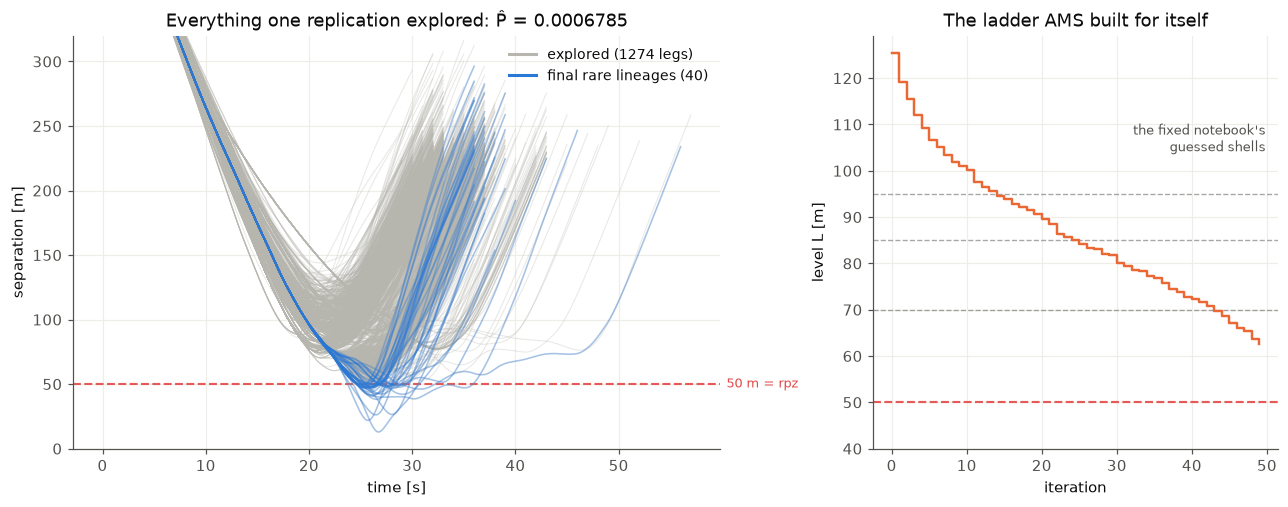

In [6]:
print(f"AMS replication 0, N = {N}, k = {K_KILL}, seed {SEED}:")
rep0, cloud0, explored0 = ams_once(child(root_seed_sequence(SEED), 0), N, K_KILL,
                                   verbose=True)
print(f"\n  P̂ = {np.prod(rep0.factors):.4g} × {rep0.n_rare}/{N} = {rep0.prob:.4g}")
print(f"  cost: {rep0.n_legs} episode legs ({N} initial + {rep0.n_legs - N} branches) "
      f"over {len(rep0.levels)} iterations")
print(f"  replays behind it: {N_REPLAYS['spawn']} from a respawned seed, "
      f"{N_REPLAYS['branch']} from a branch snapshot — every one bit-identical")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.6, 4.5), width_ratios=(1.6, 1))
for traj in explored0:
    a = np.asarray(traj)
    ax0.plot(a[:, 0], a[:, 1], color=GRAY, lw=0.7, alpha=0.30, zorder=2)
rare = [p.inh + p.leg for p in cloud0 if p.score < RPZ]
for traj in rare:
    a = np.asarray(traj)
    ax0.plot(a[:, 0], a[:, 1], color=BLUE, lw=1.1, alpha=0.35, zorder=3)
ax0.axhline(RPZ, color=RED, lw=1.4, ls="--", alpha=0.9, zorder=1)
ax0.annotate(f"{RPZ:g} m = rpz", xy=(1.0, RPZ), xycoords=("axes fraction", "data"),
             xytext=(4, 0), textcoords="offset points", va="center",
             fontsize=8.5, color=RED)
ax0.plot([], [], color=GRAY, lw=2, label=f"explored ({len(explored0)} legs)")
ax0.plot([], [], color=BLUE, lw=2, label=f"final rare lineages ({len(rare)})")
ax0.legend(frameon=False, loc="upper right", fontsize=9)
ax0.set(xlabel="time [s]", ylabel="separation [m]", ylim=(0, 320),
        title=f"Everything one replication explored: P̂ = {rep0.prob:.4g}")

ax1.step(range(len(rep0.levels)), rep0.levels, where="post", color=ORANGE, lw=1.6)
for d in (95.0, 85.0, 70.0):
    ax1.axhline(d, color=MUTED, lw=0.9, ls="--", alpha=0.5, zorder=1)
ax1.axhline(RPZ, color=RED, lw=1.4, ls="--", alpha=0.9, zorder=1)
ax1.annotate("the fixed notebook's\nguessed shells", xy=(0.97, 0.72),
             xycoords="axes fraction", ha="right", fontsize=8.5, color=MUTED)
ax1.set(xlabel="iteration", ylabel="level L [m]", ylim=(40, None),
        title="The ladder AMS built for itself")
plt.show()

## 5 · What can be verified — and the pathology worth knowing about

With no packaged AMS to reproduce, the checks are the ones already riding inside the
run: the initial cloud **is** `run_episode` (asserted, section 1), and all of the
branch replays above reproduced their parent's record bit for bit (asserted, every
call). What remains is statistical: independent replications, and a ratio against the
packaged fixed-level anchor on the same cell, at the same `N`.

**First, the pathology.** Those kill counts above `k` are score **atoms**. A branch
lands one whole step past the crossing — at `dt = 0.2 s` and ~21 m/s closure that is a
~4 m plunge, easily straight onto the parent's closest approach. From there the
resolution is already winning, the aircraft are separating, and a clone's fresh noise
frequently never beats the minimum it inherited — so its score is the parent's score,
*exactly*, and families of identical scores accumulate. When the level reaches such a
family and the ties are killed together, a replication can lose its whole cloud at
once: **extinction**, AMS's version of the fixed ladder's empty shell — not
mis-placed levels, but a cloud captured by its own atoms. One of the replications
below does exactly this. The convention is the fixed estimator's: `P̂ = 0`, counted,
never hidden — and the honest mitigation is the same too: independent replications
(and a larger `N`), not a fix-up of the run that died.

The comparison is judged on the **ratio** of point estimates — no intervals, per this
package's convention; with three replications a factor of ~2 either way is spread, not
signal. And do not expect the fixed-level anchor to be steady either: this cell at
those four shells is precisely where fixed levels go empty, and its own collapsed
count below shows it. Both splitting estimators wear their failure modes openly here —
which is why the Monte-Carlo pilot of this cell (13 events in 4000 episodes) rides
along as the sturdiest reference. Note what the cost column says: each AMS replication
reached the boundary for a few hundred episode legs — plain MC at this cell's
probability sees one event per ~300 episodes, so an estimate resolved to a few percent
would need tens of thousands.

In [7]:
from blueskycdarr.ips import estimate_rare_prob   # the fixed-level anchor — comparison only

reps = [rep0]
for r in (1, 2):
    rep, _, _ = ams_once(child(root_seed_sequence(SEED), r), N, K_KILL)
    reps.append(rep)

print(f"{'rep':>4} {'P̂':>10} {'iters':>6} {'legs':>5} {'n_rare':>7}   note")
for r, rr in enumerate(reps):
    note = "extinct" if rr.extinct else ("capped" if rr.capped else "")
    print(f"{r:4d} {rr.prob:10.4g} {len(rr.levels):6d} {rr.n_legs:5d} "
          f"{rr.n_rare:7d}   {note}")
p_ams = float(np.mean([r.prob for r in reps]))
n_extinct = sum(r.extinct for r in reps)
print(f"\nAMS mean of {len(reps)} replications ({n_extinct} extinct, counted): "
      f"{p_ams:.4g}")

est = estimate_rare_prob(SCENARIO, MULTIROTOR, CONFIG,
                         levels=[95.0, 85.0, 70.0, 50.0],
                         n_particles=N, reps=3, seed=SEED)
print(f"fixed-level anchor, same N and seed, 3 replications: {est.p_los:.4g} "
      f"({est.n_collapsed} collapsed)")
print(f"MC pilot of this cell: 13/4000 = {13 / 4000:.4g}")
print(f"\nratio  AMS / fixed-level         = {p_ams / est.p_los:.2f}")
print(f"ratio  AMS / MC pilot            = {p_ams / (13 / 4000):.2f}")
print(f"ratio  fixed-level / MC pilot    = {est.p_los / (13 / 4000):.2f}")

assert not any(r.capped for r in reps), "a replication hit MAX_ITERS"
total_replays = N_REPLAYS["spawn"] + N_REPLAYS["branch"]
print(f"\n{total_replays} branch replays across all replications, "
      "every one asserted bit-identical to its parent's record")

 rep         P̂  iters  legs  n_rare   note
   0  0.0006785     50  1274      40   capped
   1   0.005612     44  1161     184   
   2     0.0136     38  1002     189   

AMS mean of 3 replications (0 extinct, counted): 0.006629
fixed-level anchor, same N and seed, 3 replications: 0.004966 (0 collapsed)
MC pilot of this cell: 13/4000 = 0.00325

ratio  AMS / fixed-level         = 1.33
ratio  AMS / MC pilot            = 2.04
ratio  fixed-level / MC pilot    = 1.53


AssertionError: a replication hit MAX_ITERS